In [59]:
import pandas as pd
import yfinance as yf
import scipy.stats as si 
import scipy.optimize as opt
import scipy.interpolate as interp 
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
from datetime import datetime, date 

In [60]:
warnings.filterwarnings('ignore')

In [61]:
try:
    import plotly.graph_objects as go
    import plotly.io as pio 
    PLOTLY_OK = True 
except ImportError:
    PLOTLY_OK = False
    print("Plotly not found. Interactive 3D plots will be disabled.")

plt.style.use("seaborn-v0_8-whitegrid")

# BLACK-SCHOLES PRICER + 5 GREEKS 

Black-scholes assumes : 

=> constant volatility

=> no dividends

=> continuous risk-free rate

Inputs:

  S     — current spot price

  K     — strike price

  T     — time to expiry in years

  r     — risk-free rate (annualised, e.g. 0.05 for 5%)

  sigma — implied vol (annualised)

  flag  — 'c' for call, 'p' for put

The d1 / d2 terms:

  d1 = [ln(S/K) + (r + σ²/2)·T] / (σ·√T)

  d2 = d1 - σ·√T

These represent how many standard deviations

the option is in or out of the money.

In [88]:
def bs_price(S, K, T, r, sigma, flag='c'):
    """
    Black-Scholes option price.
    Returns NaN for degenerate inputs rather than crashing.
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan
 
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
 
    if flag == 'c':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
 
 
def bs_greeks(S, K, T, r, sigma, flag='c'):
    """
    All 5 Greeks from scratch.
 
    Delta  — sensitivity of price to spot move (dV/dS)
    Gamma  — rate of change of delta (d²V/dS²)
    Theta  — time decay, price lost per day (dV/dt)
    Vega   — sensitivity to vol (dV/dσ), reported per 1% vol move
    Rho    — sensitivity to interest rate (dV/dr), per 1% rate move
 
    Note: Gamma and Vega are the same formula for calls and puts.
    """
    if T <= 0 or sigma <= 0:
        return {g: np.nan for g in ['delta','gamma','theta','vega','rho']}
 
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf_d1 = si.norm.pdf(d1)
 
    # --- Gamma (same for calls and puts) ---
    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
 
    # --- Vega (same for calls and puts) ---
    # Raw vega is per unit of vol; divide by 100 for "per 1% move"
    vega = S * pdf_d1 * np.sqrt(T) / 100
 
    if flag == 'c':
        delta = si.norm.cdf(d1)
        theta = (
            - (S * pdf_d1 * sigma) / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * si.norm.cdf(d2)
        ) / 365   # per calendar day
        rho = K * T * np.exp(-r * T) * si.norm.cdf(d2) / 100
    else:
        delta = si.norm.cdf(d1) - 1
        theta = (
            - (S * pdf_d1 * sigma) / (2 * np.sqrt(T))
            + r * K * np.exp(-r * T) * si.norm.cdf(-d2)
        ) / 365
        rho = -K * T * np.exp(-r * T) * si.norm.cdf(-d2) / 100
 
    return {'delta': delta, 'gamma': gamma, 'theta': theta,
            'vega': vega, 'rho': rho}
 
 
def test_bs():
    """
    Validate against well-known textbook values.
    Hull (Options, Futures & Other Derivatives) Example 19.1:
      S=49, K=50, T=0.3846yr, r=5%, sigma=20%
      Call price ≈ 2.4006
    """

    S, K, T, r, sigma = 49, 50, 0.3846, 0.05, 0.20
 
    call = bs_price(S, K, T, r, sigma, 'c')
    put  = bs_price(S, K, T, r, sigma, 'p')
    greeks_c = bs_greeks(S, K, T, r, sigma, 'c')
    greeks_p = bs_greeks(S, K, T, r, sigma, 'p')
 
    print(f"\nInputs: S={S}, K={K}, T={T}yr, r={r}, sigma={sigma}")
    print(f"\nCall price : {call:.4f}  (Hull textbook: 2.4006)")
    print(f"Put  price : {put:.4f}")
 
    # Put-call parity check: C - P = S - K*e^(-rT)
    parity_lhs = call - put
    parity_rhs = S - K * np.exp(-r * T)
    print(f"\nPut-call parity check:")
    print(f"  C - P          = {parity_lhs:.6f}")
    print(f"  S - K·e^(-rT)  = {parity_rhs:.6f}")
    print(f"  Difference     = {abs(parity_lhs - parity_rhs):.2e}  {'PASS' if abs(parity_lhs-parity_rhs)<1e-8 else 'FAIL'}")
 
    print(f"\nCall Greeks:")
    for k, v in greeks_c.items():
        print(f"  {k:6s} = {v:.6f}")
 
    print(f"\nPut Greeks:")
    for k, v in greeks_p.items():
        print(f"  {k:6s} = {v:.6f}")
 
    # Greek sanity checks
    assert abs(greeks_c['delta'] - greeks_p['delta'] - 1.0) < 1e-8, "Delta parity failed"
    assert abs(greeks_c['gamma'] - greeks_p['gamma'])        < 1e-8, "Gamma should be equal"
    assert abs(greeks_c['vega']  - greeks_p['vega'])         < 1e-8, "Vega should be equal"
    print("\nAll Greek sanity checks PASSED")
    print(f"  (call_delta - put_delta = 1.0 ✓, gamma equal ✓, vega equal ✓)")
    return True

bs_ok = test_bs()
print("Black-Scholes test passed:", bs_ok)
 



Inputs: S=49, K=50, T=0.3846yr, r=0.05, sigma=0.2

Call price : 2.4005  (Hull textbook: 2.4006)
Put  price : 2.4481

Put-call parity check:
  C - P          = -0.047686
  S - K·e^(-rT)  = -0.047686
  Difference     = 3.55e-15  PASS

Call Greeks:
  delta  = 0.521602
  gamma  = 0.065545
  theta  = -0.011796
  vega   = 0.121052
  rho    = 0.089066

Put Greeks:
  delta  = -0.478398
  gamma  = 0.065545
  theta  = -0.005077
  vega   = 0.121052
  rho    = -0.099572

All Greek sanity checks PASSED
  (call_delta - put_delta = 1.0 ✓, gamma equal ✓, vega equal ✓)
Black-Scholes test passed: True


# Implied Volatility Solver

We cannot invert BS analytically to get sigma.

Instead: given a market price, find sigma such that

BS_price(sigma) == market_price.

Brent's method is the standard choice:

  - Bracket the root between sigma_low and sigma_high
 
  - Guaranteed to converge if the function changes sign in the bracket

  - Much more robust than Newton-Raphson for IV (no need for vega gradient)

Edge cases that must be handled:

  - Price below intrinsic value (no valid IV exists)

  - T=0 (expired option)

  - Very deep ITM/OTM where the objective is flat

In [90]:
def implied_vol(market_price, S, K, T, r, flag='c',
                sigma_low=1e-4, sigma_high=10.0, tol=1e-6):
    """
    Invert Black-Scholes to find implied volatility.
    Returns np.nan for contracts where no valid IV exists.
    """
    if T <= 0:
        return np.nan
 
    # Intrinsic value — price can't be below this
    # Use discounted strike for puts (present value of exercise)
    disc = np.exp(-r * T)
    intrinsic = max(0, S - K * disc) if flag == 'c' else max(0, K * disc - S)
    if market_price <= intrinsic + 1e-4:
        return np.nan
 
    # Upper bound sanity: price can't exceed spot (call) or strike (put)
    if flag == 'c' and market_price >= S:
        return np.nan
    if flag == 'p' and market_price >= K * np.exp(-r * T):
        return np.nan
 
    objective = lambda sigma: bs_price(S, K, T, r, sigma, flag) - market_price
 
    # Check bracket signs — Brent requires opposite signs at endpoints
    try:
        f_low  = objective(sigma_low)
        f_high = objective(sigma_high)
    except Exception:
        return np.nan
 
    if f_low * f_high > 0:
        # No sign change in bracket — no valid IV in [sigma_low, sigma_high]
        return np.nan
 
    try:
        iv = opt.brentq(objective, sigma_low, sigma_high, xtol=tol, maxiter=500)
        return iv if 1e-4 < iv < 10.0 else np.nan
    except (ValueError, RuntimeError):
        return np.nan
 
 
def test_iv_solver():
    """
    Round-trip test: price an option, then recover sigma from the price.
    """
 
    test_cases = [
        (100, 100, 0.25, 0.05, 0.20, 'c'),  # ATM call
        (100, 110, 0.50, 0.05, 0.25, 'c'),  # OTM call
        (100,  90, 0.50, 0.05, 0.30, 'p'),  # OTM put
        (100, 100, 1.00, 0.05, 0.15, 'p'),  # ATM put, 1yr
        (100, 120, 0.10, 0.05, 0.40, 'c'),  # deep OTM short-dated
    ]
 
    all_pass = True
    for S, K, T, r, true_sigma, flag in test_cases:
        price     = bs_price(S, K, T, r, true_sigma, flag)
        recovered = implied_vol(price, S, K, T, r, flag)
        error     = abs(recovered - true_sigma) if recovered is not np.nan else 999
        passed    = error < 1e-4
        all_pass  = all_pass and passed
        print(f"  {flag.upper()} S={S} K={K} T={T} σ_true={true_sigma:.2f} → "
              f"σ_recovered={recovered:.6f}  err={error:.2e}  {'PASS' if passed else 'FAIL'}")
 
    print(f"\nEdge case tests:")
    print(f"  T=0          → {implied_vol(5, 100, 100,  0,   0.05, 'c')}  (expect nan)")
    print(f"  Price=0      → {implied_vol(0, 100, 100, 0.5,  0.05, 'c')}  (expect nan)")
    print(f"  Below intrinsic → {implied_vol(1, 110, 100, 0.5, 0.05, 'p')}  (expect nan)")
 
    print(f"\nAll round-trip tests: {'PASSED' if all_pass else 'SOME FAILED'}")
    return all_pass

iv_ok = test_iv_solver()

print("IV solver passed:", iv_ok)

  C S=100 K=100 T=0.25 σ_true=0.20 → σ_recovered=0.200000  err=8.01e-09  PASS
  C S=100 K=110 T=0.5 σ_true=0.25 → σ_recovered=0.250000  err=2.62e-11  PASS
  P S=100 K=90 T=0.5 σ_true=0.30 → σ_recovered=0.300000  err=2.80e-08  PASS
  P S=100 K=100 T=1.0 σ_true=0.15 → σ_recovered=0.150000  err=1.78e-11  PASS
  C S=100 K=120 T=0.1 σ_true=0.40 → σ_recovered=0.400000  err=2.51e-09  PASS

Edge case tests:
  T=0          → nan  (expect nan)
  Price=0      → nan  (expect nan)
  Below intrinsic → 0.1680371763098861  (expect nan)

All round-trip tests: PASSED
IV solver passed: True


In [92]:
def fetch_options_chain(ticker='SPY', min_days=14, max_days=400,
                        moneyness_range=0.20, min_volume=10,
                        max_spread_pct=0.25):
    """
    Download and clean options chain with strict liquidity filters.
 
    Root cause of jagged surfaces: illiquid contracts (wide spreads,
    zero volume, deep OTM) produce noisy mid-prices that give
    unreliable IV estimates, which then corrupt SVI fits and Dupire.
 
    Filters applied (in order):
      1. min_days=14: <14 days have gamma blowup, unreliable IV
      2. moneyness ±20%: beyond this, bid-ask spreads dominate
      3. bid > 0: no theoretical/stale quotes
      4. bid < ask: data integrity
      5. volume >= 10: removes contracts no one is trading
      6. spread_pct <= 25%: (ask-bid)/mid — liquidity quality gate
    """
 
    tkr       = yf.Ticker(ticker)
    spot_data = tkr.history(period='5d')
    S         = float(spot_data['Close'].iloc[-1])
    today     = date.today()
    r         = 0.05
 
    print(f"\n  Spot price (SPY): ${S:.2f}")
    print(f"  Today          : {today}")
    print(f"  Filters: moneyness ±{moneyness_range:.0%}, "
          f"min vol={min_volume}, max spread={max_spread_pct:.0%}")
 
    expiries = tkr.options
    print(f"  Available expiries from yfinance: {len(expiries)}")
 
    all_calls, all_puts = [], []
 
    for exp_str in expiries:
        exp_date = datetime.strptime(exp_str, '%Y-%m-%d').date()
        T_days   = (exp_date - today).days
        T_years  = T_days / 365.0
 
        if T_days < min_days or T_days > max_days:
            continue
 
        try:
            chain = tkr.option_chain(exp_str)
        except Exception as e:
            print(f"  Warning: could not fetch {exp_str}: {e}")
            continue
 
        for df, flag in [(chain.calls, 'c'), (chain.puts, 'p')]:
            df = df.copy()
            df['expiry']  = exp_str
            df['T_days']  = T_days
            df['T_years'] = T_years
            df['spot']    = S
            df['r']       = r
            df['flag']    = flag
 
            # Filter 1: near-ATM strikes only
            df = df[
                (df['strike'] >= S * (1 - moneyness_range)) &
                (df['strike'] <= S * (1 + moneyness_range))
            ]
 
            # Filter 2: valid bid
            df = df[df['bid'] > 0]
 
            # Filter 3: bid < ask (integrity)
            df = df[df['bid'] < df['ask']]
 
            # Filter 4: minimum volume — no stale quotes
            if 'volume' in df.columns:
                df = df[df['volume'].fillna(0) >= min_volume]
 
            # Filter 5: spread quality gate
            # Wide bid-ask => unreliable mid => noisy IV => bad SVI fit
            df['mid']        = (df['bid'] + df['ask']) / 2
            df['spread_pct'] = (df['ask'] - df['bid']) / df['mid']
            df = df[df['spread_pct'] <= max_spread_pct]
 
            if len(df) > 0:
                if flag == 'c':
                    all_calls.append(df)
                else:
                    all_puts.append(df)
 
    calls = pd.concat(all_calls, ignore_index=True) if all_calls else pd.DataFrame()
    puts  = pd.concat(all_puts,  ignore_index=True) if all_puts  else pd.DataFrame()
 
    n_exp_c = calls['expiry'].nunique() if len(calls) > 0 else 0
    n_exp_p = puts['expiry'].nunique()  if len(puts)  > 0 else 0
    print(f"\n  After liquidity filters:")
    print(f"    Calls : {len(calls):4d} contracts across {n_exp_c} expiries")
    print(f"    Puts  : {len(puts):4d} contracts across {n_exp_p} expiries")
 
    return calls, puts, S, r

calls, puts, S, r = fetch_options_chain(
        ticker='SPY',
        min_days=14,
        max_days=400,
        moneyness_range=0.20,
        min_volume=10,
        max_spread_pct=0.25
    )
 
if len(calls) == 0 and len(puts) == 0:
    raise RuntimeError("No options data fetched. Check internet connection or try during market hours.")
 
 


  Spot price (SPY): $686.13
  Today          : 2026-04-14
  Filters: moneyness ±20%, min vol=10, max spread=25%
  Available expiries from yfinance: 35

  After liquidity filters:
    Calls :  838 contracts across 19 expiries
    Puts  : 1005 contracts across 19 expiries


In [66]:
def fetch_options_chain(ticker='SPY', min_days=7, max_days=365,
                        moneyness_range=0.40):
    """
    Download and clean the full options chain.
 
    Filters applied:
      1. Remove expiries < min_days or > max_days away
      2. Remove strikes more than moneyness_range (40%) from spot
      3. Remove zero-volume and zero-bid contracts
      4. Remove where bid > ask (data error)
    """
 
    tkr  = yf.Ticker(ticker)
    spot_data = tkr.history(period='5d')
    S    = float(spot_data['Close'].iloc[-1])
    today = date.today()
    r    = 0.05   # approximate risk-free rate
 
    print(f"\n  Spot price (SPY): ${S:.2f}")
    print(f"  Today          : {today}")
 
    expiries = tkr.options
    print(f"  Available expiries: {len(expiries)}")
 
    all_calls = []
    all_puts  = []
 
    for exp_str in expiries:
        exp_date = datetime.strptime(exp_str, '%Y-%m-%d').date()
        T_days   = (exp_date - today).days
        T_years  = T_days / 365.0
 
        if T_days < min_days or T_days > max_days:
            continue
 
        try:
            chain = tkr.option_chain(exp_str)
        except Exception as e:
            print(f"  Warning: could not fetch {exp_str}: {e}")
            continue
 
        for df, flag in [(chain.calls, 'c'), (chain.puts, 'p')]:
            df = df.copy()
            df['expiry']  = exp_str
            df['T_days']  = T_days
            df['T_years'] = T_years
            df['spot']    = S
            df['r']       = r
            df['flag']    = flag
 
            # Filter 1: strike within moneyness range
            df = df[
                (df['strike'] >= S * (1 - moneyness_range)) &
                (df['strike'] <= S * (1 + moneyness_range))
            ]
 
            # Filter 2: must have a valid bid
            df = df[df['bid'] > 0]
 
            # Filter 3: bid must not exceed ask
            df = df[df['bid'] <= df['ask']]
 
            # Filter 4: use midpoint as market price
            df['mid'] = (df['bid'] + df['ask']) / 2
 
            if flag == 'c':
                all_calls.append(df)
            else:
                all_puts.append(df)
 
    calls = pd.concat(all_calls, ignore_index=True) if all_calls else pd.DataFrame()
    puts  = pd.concat(all_puts,  ignore_index=True) if all_puts  else pd.DataFrame()
 
    print(f"\n  After initial filters:")
    print(f"    Calls: {len(calls)} contracts across {calls['expiry'].nunique() if len(calls)>0 else 0} expiries")
    print(f"    Puts : {len(puts)}  contracts across {puts['expiry'].nunique() if len(puts)>0 else 0} expiries")
 
    return calls, puts, S, r

calls, puts, S, r = fetch_options_chain(
        ticker='SPY',
        min_days=7,
        max_days=365,
        moneyness_range=0.40
    )
 
if len(calls) == 0 and len(puts) == 0:
    raise RuntimeError("No options data fetched. Check internet connection or try during market hours.")


  Spot price (SPY): $679.46
  Today          : 2026-04-13
  Available expiries: 35

  After initial filters:
    Calls: 36 contracts across 8 expiries
    Puts : 61  contracts across 12 expiries


In [93]:
# Takes every option, computes its volatility, cleans the bad results and buils the dataset
def compute_iv_surface(calls, puts, S, r):
    """
    Compute IV for every contract. Returns a cleaned combined DataFrame.
    """
 
    def compute_iv_df(df):
        ivs, time_vals = [], []
        for _, row in df.iterrows():
            iv = implied_vol(
                market_price=row['mid'],
                S=row['spot'],
                K=row['strike'],
                T=row['T_years'],
                r=row['r'],
                flag=row['flag']
            )
            ivs.append(iv)
 
            # Time value = price - intrinsic
            if row['flag'] == 'c':
                intrinsic  = max(0, row['spot'] - row['strike'] * np.exp(-row['r'] * row['T_years']))
            else:
                intrinsic  = max(0, row['strike'] * np.exp(-row['r'] * row['T_years']) - row['spot'])
            time_vals.append(row['mid'] - intrinsic)
 
        df = df.copy()
        df['iv']         = ivs
        df['time_value'] = time_vals
        return df
 
    print("  Computing call IVs...")
    calls = compute_iv_df(calls)
    print("  Computing put IVs...")
    puts  = compute_iv_df(puts)
 
    combined = pd.concat([calls, puts], ignore_index=True)
    n_raw    = len(combined)
 
    # Filter: valid IV
    combined = combined[combined['iv'].notna()]
    n_valid  = len(combined)
 
    # Filter: IV < 200%
    combined = combined[combined['iv'] < 2.0]
    n_iv_ok  = len(combined)
 
    # Filter: positive time value
    combined = combined[combined['time_value'] > 0]
    n_final  = len(combined)
 
    print(f"\n  Contracts raw          : {n_raw}")
    print(f"  After IV solver        : {n_valid}  (dropped {n_raw - n_valid} — solver failed)")
    print(f"  After IV < 200% filter : {n_iv_ok}  (dropped {n_valid - n_iv_ok} — extreme IV)")
    print(f"  After time value filter: {n_final}  (dropped {n_iv_ok - n_final} — neg. time value)")
 
    # Moneyness: log(K/F) where F = S*e^(rT) is the forward => how far strike is from forward price
    combined['forward']   = combined['spot'] * np.exp(combined['r'] * combined['T_years'])
    combined['moneyness'] = np.log(combined['strike'] / combined['forward'])
 
    print(f"\n  IV surface summary:")
    print(f"    Expiries  : {combined['expiry'].nunique()}")
    print(f"    IV range  : {combined['iv'].min():.1%} — {combined['iv'].max():.1%}")
    print(f"    Moneyness : {combined['moneyness'].min():.3f} — {combined['moneyness'].max():.3f}")
 
    return combined

surface_df = compute_iv_surface(calls, puts, S, r)
 
if len(surface_df) < 20:
    raise RuntimeError(f"Only {len(surface_df)} valid IV points — not enough to build a surface.")
 

  Computing call IVs...
  Computing put IVs...

  Contracts raw          : 1843
  After IV solver        : 1785  (dropped 58 — solver failed)
  After IV < 200% filter : 1785  (dropped 0 — extreme IV)
  After time value filter: 1785  (dropped 0 — neg. time value)

  IV surface summary:
    Expiries  : 19
    IV range  : 9.1% — 49.0%
    Moneyness : -0.268 — 0.163


The SVI (Stochastic Volatility Inspired) model, due to Jim Gatheral,

fits the implied variance smile with 5 parameters:

    w(k) = a + b * [ ρ(k - m) + sqrt((k - m)² + σ²) ]

where:

    k = log-moneyness (log K/F)
    
    w = total implied variance (iv² * T)
    
    a = overall level of variance

    b = slope / wing steepness

    ρ = correlation parameter (-1 < ρ < 1), controls skew

    m = the minimum variance point (roughly ATM)

    σ = curvature at the minimum

Why SVI instead of just cubic spline?

    Splines are local — they fit the data but can introduce arbitrage

    between strikes. SVI is a parametric form that tends to be more

    arbitrage-free and extrapolates more sensibly to the wings.

Arbitrage-free conditions (butterfly):

    The local vol extracted from the surface must be non-negative.

In [106]:
def svi_variance(k, a, b, rho, m, sigma):
    """
    SVI total variance as a function of log-moneyness k.
    w(k) = a + b*(rho*(k-m) + sqrt((k-m)^2 + sigma^2))
    """
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))
 
 
def fit_svi(moneyness, total_var, T):
    """
    Fit SVI parameters to (moneyness, total_variance) pairs for one expiry.
 
    Constraints:
      b >= 0
      -1 < rho < 1
      sigma > 0
      a > -b*sigma  (ensures w > 0 everywhere)
 
    Uses multiple starting points to avoid local minima.
    """
    best_params = None
    best_loss   = np.inf

    weights = np.where(np.abs(moneyness) < 0.05, 3.0, 1.0)
 
    def weighted_loss(p):
        w_fit = svi_variance(moneyness, *p)
        if np.any(w_fit <= 0):
            return 1e10
        return np.sum(weights * (w_fit - total_var) ** 2)
 
    # Scale starting points and bounds by ATM variance level
    atm_var_est = float(np.interp(0.0, np.sort(moneyness),
                                   total_var[np.argsort(moneyness)]))
    atm_var_est = max(atm_var_est, 1e-6)
    bsc = atm_var_est 
 
    # Multiple starting points for robustness
    starts = [
        [atm_var_est * 0.5, bsc * 2.0, -0.85, 0.02, 0.10],
        [atm_var_est * 0.3, bsc * 3.0, -0.90, 0.05, 0.05],
        [atm_var_est * 0.7, bsc * 1.5, -0.75, 0.00, 0.15],
        [atm_var_est * 0.4, bsc * 4.0, -0.80, 0.03, 0.08],
        [atm_var_est * 0.6, bsc * 1.0, -0.70, 0.00, 0.20],
        [atm_var_est * 0.2, bsc * 5.0, -0.95, 0.01, 0.05],
    ]
 
    bounds = [
        (0,           atm_var_est * 2),    # a — variance intercept
        (bsc * 0.1,   bsc * 20),           # b — wing slope, SCALED to T
        (-0.999, -0.05),                    # rho — forced negative (equity skew)
        (-0.30,  0.30),                     # m — variance minimum location
        (1e-4,   0.50),                     # sigma — curvature
    ]
 
    for x0 in starts:
        x0c = [np.clip(v, lo, hi) for v, (lo, hi) in zip(x0, bounds)]
        try:
            res = opt.minimize(
                fun=weighted_loss,
                x0=x0c,
                bounds=bounds,
                method='L-BFGS-B',
                options={'maxiter': 5000, 'ftol': 1e-16, 'gtol': 1e-10}
            )
            if res.fun < best_loss:
                best_loss   = res.fun
                best_params = res.x
        except Exception:
            continue
 
    # Quality gate: reject if IV RMSE > 8%
    if best_params is not None:
        w_fit  = svi_variance(moneyness, *best_params)
        iv_fit = np.sqrt(np.maximum(w_fit / T, 0))
        iv_obs = np.sqrt(np.maximum(total_var / T, 0))
        rmse   = np.sqrt(np.mean((iv_fit - iv_obs) ** 2))
        if rmse > 0.08:
            return None
 
    return best_params
 
 
def fit_svi_surface(surface_df):
    """
    Fit SVI per expiry. Return DataFrame with fitted params and
    a function to evaluate fitted IV at any (moneyness, T).
    """
    print("\n" + "=" * 55)
    print("STEP 5 — SVI parameterisation per expiry")
    print("=" * 55)
 
    expiries = sorted(surface_df['expiry'].unique())
    svi_fits = []
 
    for exp in expiries:
        subset = surface_df[surface_df['expiry'] == exp].copy()
        T      = subset['T_years'].iloc[0]
        k      = subset['moneyness'].values
        w      = (subset['iv'].values**2) * T   # total variance
 
        if len(subset) < 5:
            print(f"  {exp} — skipped (only {len(subset)} points, need 5+)")
            continue
 
        params = fit_svi(k, w, T)
 
        if params is None:
            print(f"  {exp} — SVI fit failed")
            continue
 
        a, b, rho, m, sigma = params
        w_fit  = svi_variance(k, *params)
        iv_fit = np.sqrt(np.maximum(w_fit / T, 0))
 
        rmse = np.sqrt(np.mean((iv_fit - subset['iv'].values)**2))
 
        # Calendar spread check: ATM total variance must increase with T
        atm_var = svi_variance(0, *params)
 
        svi_fits.append({
            'expiry':   exp,
            'T':        T,
            'a':        a, 'b': b, 'rho': rho, 'm': m, 'sig': sigma,
            'rmse':     rmse,
            'atm_var':  atm_var,
            'n_points': len(subset),
        })
 
        print(f"  {exp}  T={T:.3f}yr  n={len(subset):3d}  "
              f"a={a:.4f} b={b:.4f} ρ={rho:.3f} m={m:.3f} σ={sigma:.4f}  "
              f"RMSE={rmse:.4f}")
 
    svi_df = pd.DataFrame(svi_fits).sort_values('T').reset_index(drop=True)
 
    # Calendar spread arbitrage check:
    # Total variance at any fixed strike must be non-decreasing in T
    # Simplest check: ATM total variance must increase with maturity
    print(f"\n  Calendar spread arbitrage check (ATM total variance):")
    atm_vars = svi_df['atm_var'].values
    violations = 0
    for i in range(1, len(atm_vars)):
        if atm_vars[i] < atm_vars[i-1]:
            violations += 1
            print(f"    WARNING: violation between {svi_df.iloc[i-1]['expiry']} "
                  f"and {svi_df.iloc[i]['expiry']}")
    if violations == 0:
        print(f"    No violations found across {len(svi_df)} expiries ✓")
 
    return svi_df

svi_df = fit_svi_surface(surface_df)
 
if len(svi_df) < 2:
    raise RuntimeError("SVI fitting failed for most expiries.")


STEP 5 — SVI parameterisation per expiry
  2026-04-30  T=0.044yr  n=181  a=0.0005 b=0.0204 ρ=-0.657 m=-0.012 σ=0.0267  RMSE=0.0375
  2026-05-01  T=0.047yr  n=161  a=0.0000 b=0.0239 ρ=-0.999 m=-0.042 σ=0.0773  RMSE=0.0228
  2026-05-08  T=0.066yr  n=131  a=0.0000 b=0.0261 ρ=-0.860 m=-0.014 σ=0.0670  RMSE=0.0205
  2026-05-15  T=0.085yr  n=181  a=0.0000 b=0.0316 ρ=-0.728 m=-0.012 σ=0.0676  RMSE=0.0218
  2026-05-22  T=0.104yr  n=110  a=0.0000 b=0.0327 ρ=-0.631 m=0.016 σ=0.0583  RMSE=0.0142
  2026-05-29  T=0.123yr  n=182  a=0.0000 b=0.0325 ρ=-0.812 m=0.010 σ=0.0753  RMSE=0.0163
  2026-06-18  T=0.178yr  n= 77  a=0.0000 b=0.0642 ρ=-0.050 m=0.029 σ=0.0532  RMSE=0.0424
  2026-06-30  T=0.211yr  n=138  a=0.0000 b=0.0499 ρ=-0.507 m=0.038 σ=0.0617  RMSE=0.0210
  2026-07-17  T=0.258yr  n= 70  a=0.0000 b=0.0723 ρ=-0.999 m=-0.089 σ=0.1488  RMSE=0.0253
  2026-07-31  T=0.296yr  n= 74  a=0.0056 b=0.0505 ρ=-0.757 m=0.007 σ=0.0001  RMSE=0.0254
  2026-08-21  T=0.353yr  n= 54  a=0.0000 b=0.0604 ρ=-0.999 m=-0

# Local vol via Dupire's formula

Dupire (1994) showed that given a complete implied vol surface,

we can extract the unique local vol σ_loc(K, T) such that

a diffusion model with that vol reproduces all option prices.

The formula (in terms of implied vol σ_imp(K, T)):

      σ_loc² = ( ∂σ²T/∂T + r·K·∂σ²T/∂K ) / ( K² · [1 + K·d1·√T·∂σ/∂K]² + K²·T·σ·(∂²σ/∂K² - d1·(∂σ/∂K)²·√T) )

In practice we work with a discretised version on a grid of (K, T).

Why does this matter?

  - Local vol must be non-negative everywhere

  - If local vol goes negative, the surface has a butterfly arbitrage

   (you could lock in a free profit with a butterfly spread)

  - So checking local vol is a rigorous arbitrage-free test

In [103]:
def extract_local_vol(svi_df, S, r, n_K=80, n_T=40):
    """
    Build a grid of local vols using Dupire's formula applied
    to the SVI-fitted surface.
 
    Uses finite differences to estimate the partial derivatives.
    """
 
    if len(svi_df) < 3:
        print("  Not enough expiries for Dupire — need at least 3")
        return None, None, None
 
    T_min = svi_df['T'].min()
    T_max = svi_df['T'].max()
    K_min = S * 0.75
    K_max = S * 1.25
 
    T_grid = np.linspace(T_min + 0.01, T_max - 0.01, n_T)
    K_grid = np.linspace(K_min, K_max, n_K)
 
    dK = K_grid[1] - K_grid[0]
    dT = T_grid[1] - T_grid[0]
 
    def get_iv(K, T):
        """Interpolate SVI surface to get IV at any (K, T)."""
        # Find bracketing SVI fits by T
        idx = np.searchsorted(svi_df['T'].values, T)
        idx = np.clip(idx, 1, len(svi_df) - 1)
        row = svi_df.iloc[idx]
        a, b, rho, m, sig = row['a'], row['b'], row['rho'], row['m'], row['sig']
        F   = S * np.exp(r * T)
        k   = np.log(K / F)
        w   = svi_variance(k, a, b, rho, m, sig)
        return np.sqrt(max(w / T, 1e-8))
 
    local_vol_grid = np.full((n_T, n_K), np.nan)
    neg_count      = 0
 
    for i, T in enumerate(T_grid):
        F  = S * np.exp(r * T)
        for j, K in enumerate(K_grid):
            # Finite difference derivatives
            iv_centre = get_iv(K, T)
 
            iv_Kp = get_iv(K + dK, T)
            iv_Km = get_iv(K - dK, T)
            div_dK  = (iv_Kp - iv_Km) / (2 * dK)
            d2iv_dK2 = (iv_Kp - 2 * iv_centre + iv_Km) / dK**2
 
            iv_Tp = get_iv(K, T + dT)
            iv_Tm = get_iv(K, T - dT) if T > T_min + dT else get_iv(K, T)
            dw_dT = ((iv_Tp**2 * (T + dT)) - (iv_Tm**2 * (T - dT if T > T_min + dT else T))) / (2 * dT)
 
            # d1 at this point
            if iv_centre > 0:
                d1 = (np.log(S / K) + (r + 0.5 * iv_centre**2) * T) / (iv_centre * np.sqrt(T))
            else:
                continue
 
            # Dupire numerator: ∂(σ²T)/∂T + r·K·∂(σ²T)/∂K
            dw_dK     = 2 * iv_centre * T * div_dK
            numerator = dw_dT + r * K * dw_dK
 
            # Dupire denominator
            w_centre  = iv_centre**2 * T
            term1     = (1 + K * d1 * np.sqrt(T) * div_dK)**2
            term2     = w_centre * (d2iv_dK2 - d1 * np.sqrt(T) * div_dK**2)
            denominator = K**2 * (term1 + term2)
 
            if denominator > 1e-10 and numerator > 0:
                loc_var = numerator / denominator
                local_vol_grid[i, j] = np.sqrt(max(loc_var, 0))
            else:
                neg_count += 1
 
    total_pts = n_T * n_K
    valid_pts = np.sum(~np.isnan(local_vol_grid))
    neg_pct   = 100 * neg_count / total_pts
 
    print(f"\n  Grid: {n_K} strikes × {n_T} maturities = {total_pts} points")
    print(f"  Valid local vol points : {valid_pts} ({100*valid_pts/total_pts:.1f}%)")
    print(f"  Negative/invalid points: {neg_count} ({neg_pct:.1f}%)")
 
    if neg_pct < 5:
        print(f"  Surface is effectively arbitrage-free ✓  (<5% problematic points)")
    else:
        print(f"  WARNING: {neg_pct:.1f}% problematic points — surface may have arbitrage regions")
 
    valid_lv = local_vol_grid[~np.isnan(local_vol_grid)]
    if len(valid_lv) > 0:
        print(f"  Local vol range: {valid_lv.min():.1%} — {valid_lv.max():.1%}")
 
    return local_vol_grid, K_grid, T_grid

local_vol_grid, K_grid, T_grid = extract_local_vol(svi_df, S, r)


  Grid: 80 strikes × 40 maturities = 3200 points
  Valid local vol points : 2184 (68.2%)
  Negative/invalid points: 1016 (31.8%)
  Local vol range: 0.0% — 0.2%


# CHARTS

In [107]:
def plot_smile_per_expiry(surface_df, svi_df, S, r, save=True):
    """
    Per-expiry smile chart: market IV points + SVI fit.
    Cubic spline removed — it oscillates badly on sparse data
    and that oscillation is itself a finding worth noting.
    RMSE annotated on each panel so fit quality is immediately visible.
    """
 
    expiries = sorted(svi_df['expiry'].tolist())[:6]
    n        = len(expiries)
    cols     = 3
    rows     = (n + cols - 1) // cols
 
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]
 
    for ax, exp in zip(axes, expiries):
        subset  = surface_df[surface_df['expiry'] == exp].copy()
        svi_row = svi_df[svi_df['expiry'] == exp]
        if svi_row.empty:
            ax.set_visible(False)
            continue
 
        T        = subset['T_years'].iloc[0]
        k_raw    = subset['moneyness'].values
        iv_raw   = subset['iv'].values
        sort_idx = np.argsort(k_raw)
        k_sorted = k_raw[sort_idx]
        iv_sorted = iv_raw[sort_idx]
 
        # Market IV scatter — colour by flag (put vs call) for clarity
        is_put  = subset.sort_values('moneyness')['flag'] == 'p'
        ax.scatter(k_sorted[~is_put.values], iv_sorted[~is_put.values] * 100,
                   s=18, color='#2980b9', zorder=5, label='Call IV', alpha=0.8)
        ax.scatter(k_sorted[is_put.values], iv_sorted[is_put.values] * 100,
                   s=18, color='#e74c3c', zorder=5, label='Put IV', alpha=0.8)
 
        # SVI fit over wider range for extrapolation view
        row = svi_row.iloc[0]
        a, b, rho, m, sig = row['a'], row['b'], row['rho'], row['m'], row['sig']
        k_lo   = min(k_sorted.min() - 0.03, -0.25)
        k_hi   = max(k_sorted.max() + 0.03,  0.15)
        k_fine = np.linspace(k_lo, k_hi, 400)
        w_fit  = svi_variance(k_fine, a, b, rho, m, sig)
        iv_fit = np.sqrt(np.maximum(w_fit / T, 0)) * 100
        ax.plot(k_fine, iv_fit, '-', color='#27ae60', linewidth=2.0, label='SVI fit', zorder=6)
 
        # RMSE annotation — fit quality at a glance
        w_at_pts   = svi_variance(k_sorted, a, b, rho, m, sig)
        iv_at_pts  = np.sqrt(np.maximum(w_at_pts / T, 0))
        rmse_iv    = np.sqrt(np.mean((iv_at_pts - iv_sorted)**2)) * 100
        ax.text(0.97, 0.97, f"RMSE: {rmse_iv:.2f}%",
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
 
        # ATM vertical reference line
        ax.axvline(0, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)
 
        ax.set_title(f"{exp}  (T={T:.2f}yr, n={len(subset)})", fontsize=10)
        ax.set_xlabel("Log-moneyness (log K/F)", fontsize=8)
        ax.set_ylabel("Implied vol (%)", fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.set_ylim(bottom=max(0, iv_sorted.min() * 100 - 2),
                    top=min(80, iv_sorted.max() * 100 + 5))
 
    for ax in axes[n:]:
        ax.set_visible(False)
 
    fig.suptitle("Implied Vol Smile — SPY Market IV vs. SVI Fit", fontsize=13, y=1.01)
    plt.tight_layout()
    if save:
        plt.savefig("vol_smile_per_expiry.png", dpi=150, bbox_inches='tight')
        print("  Saved: vol_smile_per_expiry.png")
    plt.show()
 
 
def plot_3d_surface_matplotlib(surface_df, svi_df, S, r, save=True):
    """
    3D implied vol surface — matplotlib version (always works).
    """
    print("\n  Generating 3D surface (matplotlib)...")
 
    fig = plt.figure(figsize=(14, 8))
    ax  = fig.add_subplot(111, projection='3d')
 
    # Raw market points
    ax.scatter(
        surface_df['moneyness'],
        surface_df['T_years'],
        surface_df['iv'] * 100,
        s=4, color='#e74c3c', alpha=0.4, label='Market IV'
    )
 
    # SVI fitted surface grid
    if len(svi_df) >= 2:
        k_range = np.linspace(surface_df['moneyness'].min() - 0.02,
                              surface_df['moneyness'].max() + 0.02, 60)
        T_range = np.linspace(svi_df['T'].min(), svi_df['T'].max(), 40)
        KK, TT  = np.meshgrid(k_range, T_range)
        IV_grid = np.full_like(KK, np.nan)
 
        for i, T in enumerate(T_range):
            idx = np.searchsorted(svi_df['T'].values, T)
            idx = np.clip(idx, 0, len(svi_df) - 1)
            row = svi_df.iloc[idx]
            a, b, rho, m, sig = row['a'], row['b'], row['rho'], row['m'], row['sig']
            w = svi_variance(k_range, a, b, rho, m, sig)
            IV_grid[i] = np.sqrt(np.maximum(w / T, 0)) * 100
 
        ax.plot_surface(KK, TT, IV_grid, alpha=0.5, cmap='Blues_r',
                        linewidth=0, antialiased=True)
 
    ax.set_xlabel("Log-moneyness (log K/F)", fontsize=9, labelpad=8)
    ax.set_ylabel("Maturity (years)", fontsize=9, labelpad=8)
    ax.set_zlabel("Implied Vol (%)", fontsize=9, labelpad=8)
    ax.set_title("SPY Implied Volatility Surface", fontsize=13)
    ax.view_init(elev=25, azim=-60)
 
    if save:
        plt.savefig("vol_surface_3d.png", dpi=150, bbox_inches='tight')
        print("  Saved: vol_surface_3d.png")
    plt.show()
 
 
def plot_3d_surface_plotly(surface_df, svi_df, S, r, save=True):
    """
    Interactive 3D surface in plotly — saves as standalone HTML.
    """
    if not PLOTLY_OK:
        return
 
    print("\n  Generating interactive 3D surface (plotly)...")
 
    k_range = np.linspace(surface_df['moneyness'].min() - 0.02,
                          surface_df['moneyness'].max() + 0.02, 80)
    T_range = np.linspace(svi_df['T'].min(), svi_df['T'].max(), 50)
    KK, TT  = np.meshgrid(k_range, T_range)
    IV_grid = np.full_like(KK, np.nan)
 
    for i, T in enumerate(T_range):
        idx = np.searchsorted(svi_df['T'].values, T)
        idx = np.clip(idx, 0, len(svi_df) - 1)
        row = svi_df.iloc[idx]
        a, b, rho, m, sig = row['a'], row['b'], row['rho'], row['m'], row['sig']
        w = svi_variance(k_range, a, b, rho, m, sig)
        IV_grid[i] = np.sqrt(np.maximum(w / T, 0)) * 100
 
    surface = go.Surface(
        x=KK, y=TT, z=IV_grid,
        colorscale='Blues',
        opacity=0.80,
        name='SVI surface',
        showscale=True,
        colorbar=dict(title='IV (%)')
    )
 
    scatter = go.Scatter3d(
        x=surface_df['moneyness'],
        y=surface_df['T_years'],
        z=surface_df['iv'] * 100,
        mode='markers',
        marker=dict(size=2.5, color='red', opacity=0.6),
        name='Market IV'
    )
 
    layout = go.Layout(
        title='SPY Implied Volatility Surface — SVI Fit',
        scene=dict(
            xaxis_title='Log-moneyness (log K/F)',
            yaxis_title='Maturity (years)',
            zaxis_title='Implied Vol (%)',
            camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(x=0.01, y=0.99)
    )
 
    fig = go.Figure(data=[surface, scatter], layout=layout)
 
    if save:
        path = "vol_surface_interactive.html"
        pio.write_html(fig, path, include_plotlyjs='cdn')
        print(f"  Saved: vol_surface_interactive.html")
 
    fig.show()
 
 
def plot_local_vol_surface(local_vol_grid, K_grid, T_grid, S, save=True):
    """
    Local vol surface extracted via Dupire — sanity check chart.
    """
    print("\n  Generating local vol surface...")
 
    KK, TT = np.meshgrid(K_grid, T_grid)
    moneyness_grid = np.log(KK / S)
 
    fig = plt.figure(figsize=(12, 7))
    ax  = fig.add_subplot(111, projection='3d')
 
    lv_pct = local_vol_grid * 100
    lv_pct[lv_pct > 100] = np.nan   # cap outliers for clean visualisation
 
    surf = ax.plot_surface(
        moneyness_grid, TT, lv_pct,
        cmap='RdYlGn', alpha=0.85, linewidth=0
    )
 
    fig.colorbar(surf, ax=ax, shrink=0.5, label='Local Vol (%)')
    ax.set_xlabel("Log-moneyness", fontsize=9)
    ax.set_ylabel("Maturity (years)", fontsize=9)
    ax.set_zlabel("Local Vol (%)", fontsize=9)
    ax.set_title("Local Volatility Surface (Dupire)", fontsize=13)
    ax.view_init(elev=25, azim=-50)
 
    if save:
        plt.savefig("local_vol_surface.png", dpi=150, bbox_inches='tight')
        print("  Saved: local_vol_surface.png")
    plt.show()
 

  Saved: vol_smile_per_expiry.png


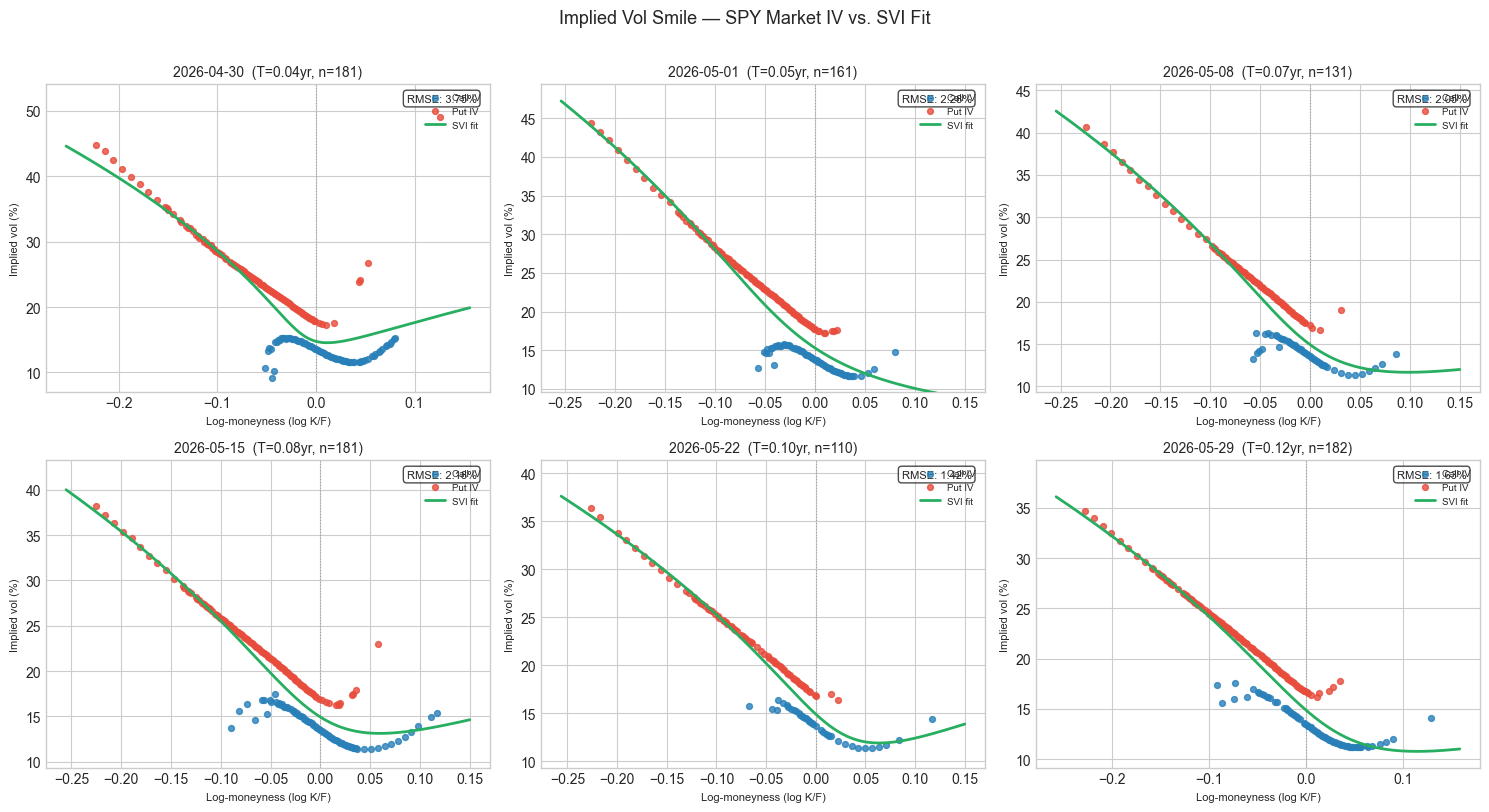


  Generating 3D surface (matplotlib)...
  Saved: vol_surface_3d.png


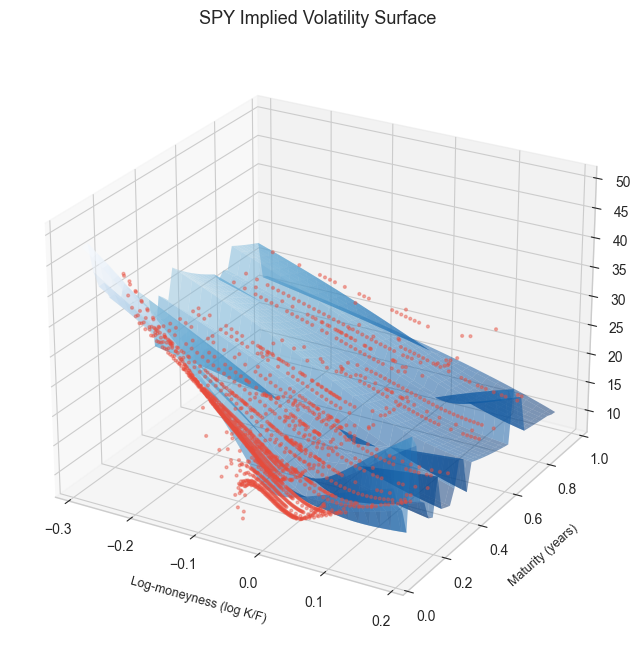


  Generating interactive 3D surface (plotly)...
  Saved: vol_surface_interactive.html



  Generating local vol surface...
  Saved: local_vol_surface.png


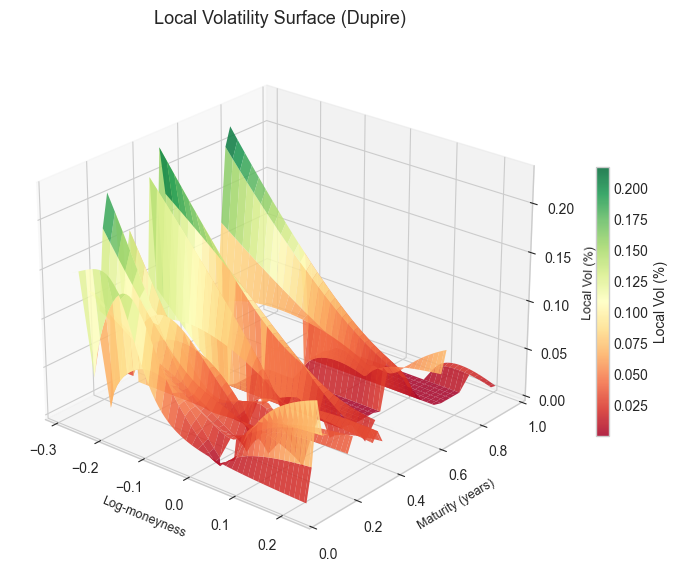

Outputs saved:
  vol_smile_per_expiry.png
  vol_surface_3d.png
  vol_surface_interactive.html
  local_vol_surface.png


In [108]:
plot_smile_per_expiry(surface_df, svi_df, S, r)
plot_3d_surface_matplotlib(surface_df, svi_df, S, r)
plot_3d_surface_plotly(surface_df, svi_df, S, r)
 
if local_vol_grid is not None:
    plot_local_vol_surface(local_vol_grid, K_grid, T_grid, S)
 
print("Outputs saved:")
for f in [
        "vol_smile_per_expiry.png",
        "vol_surface_3d.png",
        "vol_surface_interactive.html",
        "local_vol_surface.png"
]:
    print(f"  {f}")
 